#  Project Overview: Acute Lymphoblastic Leukemia (ALL) Classification

##  The Problem
Acute Lymphoblastic Leukemia (ALL) is a type of blood and bone marrow cancer that primarily affects white blood cells. Early and accurate diagnosis is critical for effective treatment planning and improving patient survival rates. Traditionally, diagnosis requires pathologists to manually examine microscopic blood smear images. This manual inspection process is highly time-consuming, labor-intensive, and can be subject to human error or fatigue.

##  Project Objective
The goal of this project is to develop an automated computer vision solution to assist medical professionals in the diagnostic process. By building and training a deep learning model—specifically a Convolutional Neural Network (CNN) using TensorFlow—we aim to accurately classify microscopic images of blood cells into four distinct categories. This AI-driven approach can significantly accelerate the analysis process and provide a reliable, objective second opinion for pathologists.

##  The Dataset
This project utilizes an image dataset containing various classes of blood cells specifically categorized for ALL classification. You can explore and download the data from the link below.

🔗 **Dataset Link:** [Blood Cell Cancer (ALL) 4 Class on Kaggle](https://www.kaggle.com/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class)

#  Environment Setup

These cells handle importing the essential libraries and connecting the file system to prepare for data processing and machine learning tasks.

---

### 1. Library Imports
| Library | Primary Function |
| :--- | :--- |
| `os` | Interacting with the operating system and managing file paths. |
| `numpy` | Numerical computing and handling multi-dimensional arrays. |
| `io.BytesIO` | Manipulating binary data (like image files) directly in memory. |
| `matplotlib.pyplot` | Creating plots, graphs, and data visualizations. |
| `tensorflow` | Building and training machine learning and deep learning models. |
| `ipywidgets` | Adding interactive UI elements (like sliders or buttons) inside Colab. |

---

### 2. Mounting Google Drive
The following command connects your Google Drive storage to the Colab environment:
`drive.mount('/content/drive')`

**Benefits:**
* Persistent access to large files and datasets.
* Saving training results and models directly to your Google account.
* Loading files easily without having to re-upload them every time you open the notebook.

---
> **Note:** The output message "Drive already mounted" appears because your drive is already actively connected for this session.

In [ ]:
import os
import numpy as np
from io import BytesIO
import matplotlib.pyplot as plt
import  tensorflow as tf
from ipywidgets import widgets


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###  Defining the Dataset Path and Checking Classes

In this cell, we specify the location of our dataset within Google Drive and verify the folders (which represent our classes) it contains.

* **`DATA_PATH`**: We store the exact path to the main dataset folder in a variable. This makes the code cleaner and easier to update.
* **`os.listdir(DATA_PATH)`**: This function lists all the contents inside the specified directory.
* **Output**: The output confirms that the dataset is structured correctly and contains exactly 4 subdirectories representing our target classes: `[Malignant] Pre-B`, `[Malignant] Pro-B`, `[Malignant] early Pre-B`, and `Benign`.

In [ ]:
DATA_PATH="/content/drive/MyDrive/Blood cell Cancer [ALL]"
print(os.listdir(DATA_PATH))

['[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B', 'Benign']


###  Loading the Training Dataset

Here, we set up our image dimensions and load the images directly from the directory into a TensorFlow dataset. This method is highly memory-efficient for training deep learning models.

* **`IMAGE_SIZE = (224, 224)`**: All images are automatically resized to 224x224 pixels. This is a standard input size required by many popular CNN architectures.
* **`BATCH_SIZE = 32`**: The model will process 32 images at a time during training before updating its weights.
* **`tf.keras.utils.image_dataset_from_directory(...)`**: This function builds the dataset pipeline based on our folder structure.
    * **`validation_split=0.2`**: We reserve 20% of the total data to evaluate the model later.
    * **`subset="training"`**: We specify that this particular dataset will hold the 80% used strictly for training.
    * **`seed=123`**: Ensures the random splitting of the data is exactly the same (reproducible) every time we run the code.
    * **`label_mode="categorical"`**: Converts the labels into a categorical (one-hot encoded) format, which is required since we are predicting between 4 different classes.

> **Result**: The function found 3,242 total images and assigned 2,594 of them to this training set.

In [ ]:
IMAGE_SIZE=(224, 224)
BATCH_SIZE=32
train_dir=tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 3242 files belonging to 4 classes.
Using 2594 files for training.


###  Loading the Validation Dataset

In this cell, we create the validation dataset using the remaining 20% of the images we reserved earlier. This separate dataset is crucial for evaluating how well our model is learning and to ensure it doesn't just memorize the training data (overfitting).

* **`subset="validation"`**: This is the key difference from the training set. It tells the function to fetch the specific 20% split defined by `validation_split=0.2`.
* All other parameters (like `IMAGE_SIZE`, `seed`, and `label_mode`) must remain exactly the same as the training dataset to ensure consistency when evaluating the model.

In [ ]:
valid_dir=tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 3242 files belonging to 4 classes.
Using 648 files for validation.


###  Building the CNN Model Architecture

In this cell, we construct the Convolutional Neural Network (CNN) that will learn to classify the blood cell images. We use a `Sequential` API to stack the layers step-by-step.

* **`tf.keras.Input(shape=(224, 224, 3))`**: Defines the expected input format. It takes images of 224x224 pixels with 3 color channels (RGB).
* **`tf.keras.layers.Rescaling(1./255)`**: Normalizes the pixel values. Standard images have pixel values from 0 to 255. This layer scales them down to a range of 0 to 1, which helps the neural network learn faster and more stably.
* **`Conv2D` Layers (Convolutional)**: These are the core building blocks of a CNN. They scan the images using filters (16 or 32 filters of size 3x3) to detect important features like edges, shapes, and textures of the blood cells. The `relu` activation function allows the model to learn complex, non-linear patterns.
* **`MaxPooling2D` Layers**: These layers downsample the image (reduce its dimensions by taking the maximum value in a 2x2 window). This significantly reduces the computational load and helps the model focus on the most prominent features while preventing overfitting.
* **`Flatten()`**: Converts the 2D feature maps outputted by the convolutional layers into a single, long 1D array. This bridges the gap between the convolutional layers and the dense layers.
* **`Dense` Layers (Fully Connected)**: These are standard neural network layers (with 128 and 64 neurons) that take the flattened features and learn the final combinations needed to make a prediction.
* **Output Layer `Dense(4, activation="softmax")`**: The final layer has exactly 4 neurons, corresponding to our 4 dataset classes. The `softmax` activation function converts the raw outputs into probabilities, meaning the model will output a percentage chance for each of the 4 classes.

In [ ]:
model=tf.keras.models.Sequential([

    tf.keras.Input(shape=(224, 224, 3)),


    #instead of manual mapping we did in level one
    tf.keras.layers.Rescaling(1./225),

    #the 1st convolutional layer

    tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    #the 2nd convolutional layer

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    #the 3rd convolutional layer

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    #building the fully connected layer

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),


    tf.keras.layers.Dense(4, activation="softmax")
])

###  Deep Dive: Understanding the Model Summary

The `model.summary()` table gives us an X-ray view of our Convolutional Neural Network. It shows exactly how the data is transformed layer by layer and how many parameters (weights and biases) the model needs to learn.

####  Understanding the Columns:
1. **Layer (type):** The name and type of the mathematical operation being applied.
2. **Output Shape:** The dimensions of the data as it leaves the layer. The `None` at the beginning represents the **batch size**, which is flexible (we set it to 32 earlier, but the model can accept any batch size).
3. **Param #:** The number of trainable weights and biases in that layer. These are the actual numbers the model tweaks during training to get better at classifying.

---

####  Layer-by-Layer Breakdown:

* **`rescaling`**:
  * **Shape:** `(None, 224, 224, 3)` - The image size and 3 color channels (RGB) remain unchanged.
  * **Params:** `0` - It just divides by 255. No learning happens here.

* **`conv2d` (16 filters):**
  * **Shape:** `(None, 222, 222, 16)` - The image shrinks slightly from 224 to 222. This happens because a 3x3 filter scanning across the image without padding shaves off the edges. The `16` represents our 16 feature maps.
  * **Params:** `448` - Calculated as: $((3 \times 3 \text{ filter size} \times 3 \text{ input channels}) + 1 \text{ bias}) \times 16 \text{ filters} = 448$.

* **`max_pooling2d`**:
  * **Shape:** `(None, 111, 111, 16)` - It cuts the spatial dimensions exactly in half (222 / 2 = 111) by keeping only the most important pixels in a 2x2 grid.
  * **Params:** `0` - Downsampling requires no learning.

* **`conv2d_1` & `max_pooling2d_1`**:
  * **Shape:** The image shrinks again to `109x109`, then pools down to `54x54` (109/2 rounds down to 54). The depth increases to `32` filters.
  * **Params:** `4,640` - The network is now learning more complex shapes based on the previous 16 filters.

* **`conv2d_2` & `max_pooling2d_2`**:
  * **Shape:** Shrinks to `52x52`, then pools down to `26x26`. Depth stays at `32`.
  * **Params:** `9,248` - Learning even higher-level features (like the specific textures of malignant cells).

* **`flatten`**:
  * **Shape:** `(None, 21632)` - It takes the 3D grid of `26x26x32` and flattens it into a single 1D array ($26 \times 26 \times 32 = 21632$).
  * **Params:** `0` - Just a reshaping operation.

* **`dense` (128 neurons):**
  * **Shape:** `(None, 128)` - The 21,632 inputs are connected to 128 neurons.
  * **Params:** `2,769,024` - Because every single input connects to every neuron, this layer holds the massive majority of the model's "brain power". Calculated as: $(21632 \times 128) + 128 \text{ biases}$.

* **`dense_1` & `dense_2` (Outputs):**
  * **Shape:** Drops to `64`, then finally down to `4` for our 4 specific leukemia classes.
  * **Params:** `8,256` and `260` respectively.

---
####  The Final Tally
* **Total parameters:** `2,791,876` (~10.65 MB of memory).
* **Trainable parameters:** All 2.79 million of them will be updated during training to learn the differences between the cell types.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,791,876 (10.65 MB)

 Trainable params: 2,791,876 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

###  Compiling the Model

Before we can start training, we need to configure the model's learning process. This step defines how the model will evaluate its own performance and how it will update its internal weights.

* **`optimizer="adam"`**: The optimizer is the algorithm that adjusts the weights of the network to minimize the loss. Adam is an industry-standard, highly efficient optimizer that dynamically adapts the learning rate during training.
* **`loss="categorical_crossentropy"`**: The loss function measures how wrong the model's predictions are. Because we are dealing with a multi-class classification problem (4 distinct classes) and our labels are one-hot encoded, `categorical_crossentropy` is the mathematically appropriate choice to calculate the error.
* **`metrics=["accuracy"]`**: This tells the model to monitor and report the accuracy (the percentage of images correctly classified) at the end of every training and validation epoch.

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

###  Optimizing the Data Pipeline for Performance

When training deep learning models, feeding data from the hard drive to the GPU can become a massive bottleneck. This cell uses TensorFlow's `tf.data` API to optimize our dataset pipelines, ensuring the GPU never sits idle waiting for images to load.

* **`cache()`**: This saves the dataset in memory after loading it from the disk during the first epoch. For all subsequent epochs, the data is read directly from memory, which drastically speeds up training.
* **`shuffle(1000)`**: Randomizes the order of the training data using a buffer size of 1000. This is crucial because it prevents the neural network from learning any unintended patterns based on the order of the files. Notice we only shuffle the training data, not the validation data.
* **`prefetch(tf.data.AUTOTUNE)`**: This is a powerful feature that allows the CPU to fetch and prepare the *next* batch of data in the background while the GPU is actively training on the *current* batch. `AUTOTUNE` lets TensorFlow automatically calculate the optimal number of batches to prepare ahead of time based on your system's resources.

In [ ]:
SHUFFLE_BUFFER_SIZE=1000
PREFETCH_BUFFER_SIZE=tf.data.AUTOTUNE

final_tarin_data=train_dir.cache().shuffle(SHUFFLE_BUFFER_SIZE).prefetch(PREFETCH_BUFFER_SIZE)

final_valid_data=valid_dir.cache().prefetch(PREFETCH_BUFFER_SIZE)


In [ ]:
history=model.fit(
    final_tarin_data,
    validation_data=final_valid_data,
    epochs=25,
    verbose=2
)

Epoch 1/25
82/82 - 471s - 6s/step - accuracy: 0.4217 - loss: 1.2706 - val_accuracy: 0.7438 - val_loss: 0.7109
Epoch 2/25
82/82 - 2s - 25ms/step - accuracy: 0.7540 - loss: 0.5882 - val_accuracy: 0.7731 - val_loss: 0.5070
Epoch 3/25
82/82 - 2s - 25ms/step - accuracy: 0.8389 - loss: 0.3902 - val_accuracy: 0.8302 - val_loss: 0.3906
Epoch 4/25
82/82 - 2s - 25ms/step - accuracy: 0.8940 - loss: 0.2649 - val_accuracy: 0.8719 - val_loss: 0.3405
Epoch 5/25
82/82 - 2s - 25ms/step - accuracy: 0.9283 - loss: 0.1989 - val_accuracy: 0.8688 - val_loss: 0.3577
Epoch 6/25
82/82 - 2s - 25ms/step - accuracy: 0.9599 - loss: 0.1119 - val_accuracy: 0.8997 - val_loss: 0.3081
Epoch 7/25
82/82 - 2s - 25ms/step - accuracy: 0.9641 - loss: 0.1029 - val_accuracy: 0.8997 - val_loss: 0.2929
Epoch 8/25
82/82 - 2s - 26ms/step - accuracy: 0.9588 - loss: 0.1173 - val_accuracy: 0.8611 - val_loss: 0.3973
Epoch 9/25
82/82 - 2s - 26ms/step - accuracy: 0.9800 - loss: 0.0561 - val_accuracy: 0.8920 - val_loss: 0.3093
Epoch 10/2

###  Training the Model

This cell is where the actual learning happens! The `model.fit()` function takes our prepared data and feeds it through the neural network.

* **`history = ...`**: We save the output of the training process into a variable named `history`. This object stores a record of the accuracy and loss values at each step, which we will use to plot our performance graphs later.
* **`final_tarin_data`**: The optimized training dataset we created in the previous step. *(Note: Watch out for the small typo in the variable name here!)*
* **`validation_data=final_valid_data`**: At the end of every epoch, the model pauses training and tests itself on this unseen validation data. This is crucial for tracking real-world performance and checking for overfitting.
* **`epochs=25`**: An epoch is one complete pass through the entire training dataset. Setting this to 25 means the model will review the full dataset 25 separate times to gradually improve its weights.
* **`verbose=2`**: This simply changes how the output logs look. `verbose=2` prints one summary line per epoch, keeping our notebook clean and easy to read.

> **Analyzing the Output:** As the epochs progress, you want to see `accuracy` and `val_accuracy` generally going up, while `loss` and `val_loss` go down. If `accuracy` hits 1.0000 (100%) but `val_accuracy` gets stuck or drops, it means the model is starting to memorize the training data rather than learning general patterns (overfitting).

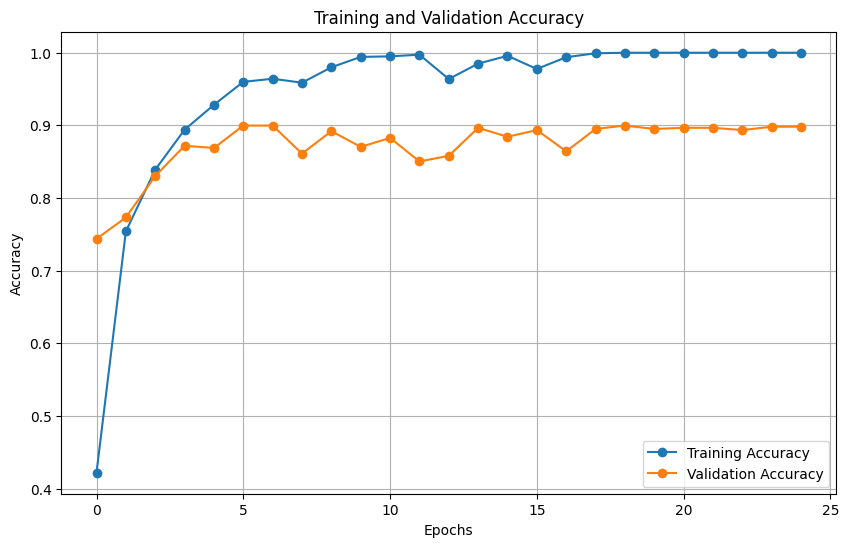

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

###  Visualizing Model Performance

In this final cell, we use the `matplotlib` library to plot the data saved in our `history` object during training. Visualizing these metrics is the best way to understand how well our model actually learned.

####  Code Breakdown:
* **`plt.figure(figsize=(10, 6))`**: Creates the canvas for our plot, setting its width to 10 inches and height to 6 inches.
* **`plt.plot(history.history["accuracy"], ...)`**: Extracts the training accuracy scores from the history dictionary and plots them as the blue line. The `marker="o"` adds the little dots at each epoch.
* **`plt.plot(history.history["val_accuracy"], ...)`**: Extracts and plots the validation accuracy scores as the orange line.
* **`plt.legend()`**: Displays the key (the box in the bottom right corner) so we know which line represents which metric.

---

####  Analyzing the Results (Diagnosis: Overfitting)
Looking at the generated graph, we can draw a very clear conclusion about the model's training process:

1. **The Blue Line (Training Accuracy):** It climbs quickly and reaches a perfect `1.0` (100%) around epoch 18. This means the model has perfectly learned how to classify every single image it was trained on.
2. **The Orange Line (Validation Accuracy):** It climbs initially but then plateaus and fluctuates roughly between `0.85` and `0.90` (85% - 90%).

**Conclusion:** Your model is experiencing **overfitting**. Because the training accuracy is perfect (100%) but the validation accuracy is stuck at ~90%, it means the network has memorized the exact details and "noise" of the training images, rather than learning the general, underlying patterns of the leukemia cells. Therefore, it struggles slightly when tested on brand new, unseen data.

In [ ]:
uploader=widgets.FileUpload(accept="image/*", multiple=True)
display(uploader)
out=widgets.Output()
display(out)


class_names = train_dir.class_names

def predict(filename, file, out):
  img=tf.keras.utils.load_img(file, target_size=IMAGE_SIZE)
  X=tf.keras.utils.img_to_array(img)
  X = np.expand_dims(X, axis=0)

  prediction=model.predict(X, verbose=0)
  predicted_class_index=np.argmax(prediction)
  predicted_class=class_names[predicted_class_index]
  confidence=np.max(prediction)* 100

  with out:
   print(f"{filename} is mostly: {predicted_class} ({confidence:.2f}%)")

def on_upload_change(change):
    items = change.new
    if isinstance(items, list):
         for item in items:
            file_jpgdata = BytesIO(item["content"])
            predict(item["name"], file_jpgdata, out)
    else:
        for filename, item in items.items():
            file_jpgdata = BytesIO(item["content"])
            predict(filename, file_jpgdata, out)

uploader.observe(on_upload_change, names="value")

FileUpload(value={}, accept='image/*', description='Upload', multiple=True)

Output()

###  Interactive Model Testing (Mini UI)

In this final cell, we build a simple, interactive user interface directly inside the notebook. This allows us to upload brand new, unseen blood cell images from our computer and have the model predict their class in real-time.

####  How the Code Works:

* **`widgets.FileUpload()` & `widgets.Output()`**: These create the graphical elements—an upload button and a dedicated text area to display our results cleanly.
* **`predict(filename, file, out)` Function**: This is the core inference engine.
  * **Preprocessing**: It loads the uploaded image and immediately resizes it to `(224, 224)` to match the format our CNN expects. It then converts the image into a mathematical array.
  * **`np.expand_dims(X, axis=0)`**: This is a crucial step! Our model was trained on *batches* of images, so it expects a 4D array `(batch_size, height, width, channels)`. This command wraps our single image inside a "batch of 1" so the model doesn't crash.
  * **`model.predict()`**: The network calculates the probabilities for all 4 leukemia classes.
  * **`np.argmax()` & Confidence**: We find the highest probability score to determine the final predicted class and multiply it by 100 to get a readable confidence percentage.
* **`on_upload_change(change)` Function**: This is an "event listener." It waits in the background, and the moment you upload a file, it reads the raw image data (`BytesIO`) and automatically feeds it into the `predict` function.